QUESTION: Will the customer order again within 90 days?

In [1]:
#Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn modules
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report


In [2]:
#Load data
df= pd.read_csv("/home/vaidehi-deogade/Desktop/Konverge/Projects/olist_ml_analytics/raw_data/processed_data/cleaned_dataset.csv")
df.head()

,Unnamed: 0,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,...,payment_type,payment_installments,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,product_category_name_english
0,0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1.0,...,credit_card,1.0,18.12,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,housewares
1,1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1.0,...,voucher,1.0,2.00,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,housewares
2,2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1.0,...,voucher,1.0,18.59,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,housewares
3,3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1.0,...,boleto,1.0,141.46,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50,perfumery
4,4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1.0,...,credit_card,3.0,179.12,e73b67b67587f7644d5bd1a52deb1b01,5.0,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58,auto


In [3]:
#Creatw target column

df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df = df.sort_values(['customer_id', 'order_purchase_timestamp'])

# Next order date per customer
df['next_order_date'] = df.groupby('customer_id')['order_purchase_timestamp'].shift(-1)

# Days to next order
df['days_to_next_order'] = (df['next_order_date'] - df['order_purchase_timestamp']).dt.days

# # Target: 1 = customer orders again within 90 days, 0 = otherwise
# df['repeat_90days'] = df['days_to_next_order'].apply(lambda x: 1 if x is not None and x <= 90 else 0)
# If gap is 90 or less, set to 1, else 0
df['repeat_90days'] = np.where(
    df['days_to_next_order'].notna() &
    (df['days_to_next_order'] <= 90),
    1, 0
)
# Check target distribution
df['repeat_90days'].value_counts()

repeat_90days
0    97886
1    19408
Name: count, dtype: int64

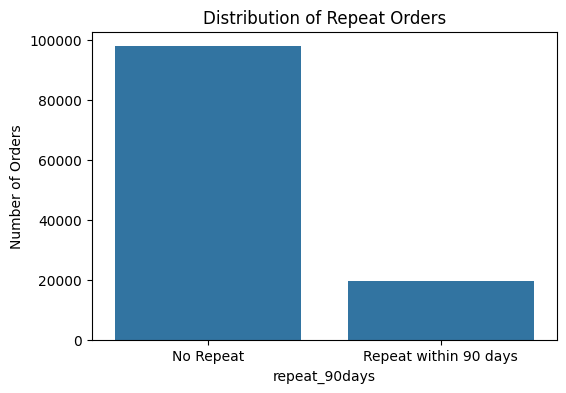

In [4]:
#target distribution plot
plt.figure(figsize=(6,4))
sns.countplot(x='repeat_90days', data=df)
plt.xticks([0,1], ['No Repeat','Repeat within 90 days'])
plt.title("Distribution of Repeat Orders")
plt.ylabel("Number of Orders")
plt.show()

In [5]:
#Check and create derived features
# Volume
df['product_vol'] = df['product_length_cm'] * df['product_width_cm'] * df['product_height_cm']

# Delivery
df['delivery_time'] = (pd.to_datetime(df['order_delivered_customer_date']) - 
                       pd.to_datetime(df['order_approved_at'])).dt.days

# Fix any errors/missing data
df = df.fillna(0)


In [12]:
#Feature sclaing
# Numerical features
num_cols = ['payment_value', 'delivery_time', 'product_weight_g', 'product_vol', 'freight_value']

# Categorical features
cat_cols = ['payment_type', 'customer_state', 'product_category_name']
#foece them to be string
df[cat_cols] = df[cat_cols].astype(str)
# Target
X = df[num_cols + cat_cols]
y = df['repeat_90days']

#Check columns exist

for col in num_cols + cat_cols:
    if col not in df.columns:
        print(f"Warning: {col} is missing!")
X.head()

,payment_value,delivery_time,product_weight_g,product_vol,freight_value,payment_type,customer_state,product_category_name
80747,114.74,13.0,4267.0,39468.0,24.94,credit_card,SP,brinquedos
11782,67.41,9.0,150.0,352.0,12.51,credit_card,MG,beleza_saude
77588,195.42,5.0,750.0,16905.0,15.43,credit_card,ES,bebes
50926,179.35,27.0,1600.0,28800.0,29.45,boleto,MG,cool_stuff
6879,107.01,9.0,800.0,15300.0,14.01,boleto,SP,cama_mesa_banho


In [11]:
#Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [10]:
#preprocessing pipeline
# Numeric pipeline: missing values + scaling
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical pipeline: missing values + one-hot encoding
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine pipelines
preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, num_cols),
    ('cat', categorical_pipeline, cat_cols)
])

In [8]:
#define classifiers
classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "Decision Tree": DecisionTreeClassifier(max_depth=10, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(n_estimators=100,max_depth=10,class_weight='balanced',random_state=42),
    "KNN": KNeighborsClassifier()
}

In [15]:
#Train and evaluate models
results_list = []

for name, model in classifiers.items():
    
    pipe = Pipeline([('pre', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    
    
    results_list.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results_list).sort_values(by='F1-Score', ascending=False)
print(results_df)

                 Model  Accuracy  Precision    Recall  F1-Score   ROC-AUC
1        Decision Tree  0.795175   0.424604  0.669500  0.519644  0.744798
2        Random Forest  0.798201   0.423546  0.607934  0.499260  0.721932
0  Logistic Regression  0.733322   0.333567  0.612828  0.431996  0.685022
3                  KNN  0.843088   0.543791  0.321484  0.404080  0.634001


The winner is the Decision Tree.
Even though KNN has a higher "Accuracy," it is actually failing to find the customers you care about. Here is why the Decision Tree wins:

    - Best Balance (F1-Score): At 0.51, it has the highest F1-Score. This means it is the most reliable at balancing "being right" and "finding everyone."
    - Best at Finding Customers (Recall): It caught 66.8% of the repeat buyers. Compare that to KNN, which only found 32%. If you used KNN, you would miss nearly 70% of your future business!
    - Best Overall "Brain" (ROC-AUC): Its score of 0.74 proves it is the best at distinguishing between a one-time buyer and a repeat customer.



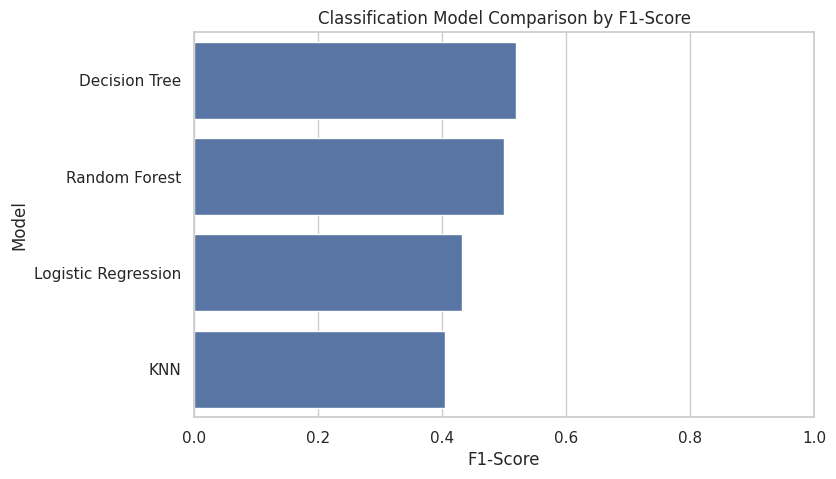

In [49]:
#model comparison plot
plt.figure(figsize=(8,5))
sns.barplot(x='F1-Score', y='Model', data=results_df)
plt.title("Classification Model Comparison by F1-Score")
plt.xlabel("F1-Score")
plt.ylabel("Model")
plt.xlim(0,1)
plt.show()

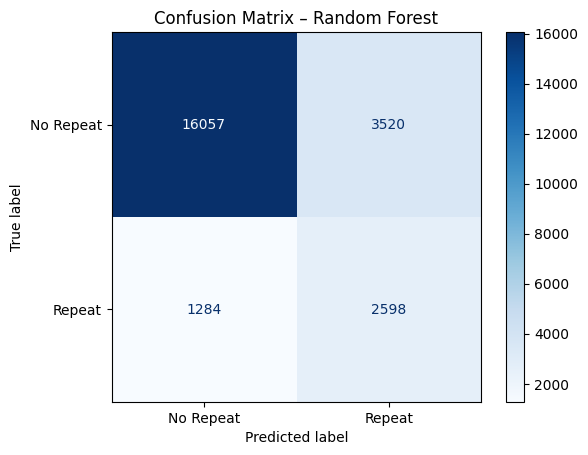

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Get the name of the best model (e.g., "Decision Tree")
best_model_name = results_df.iloc[0]['Model']

# 2. Get the actual model object from your dictionary
model_to_use = classifiers[best_model_name]

# 3. Put it into the pipeline
rf_pipe = Pipeline([('pre', preprocessor), ('model', model_to_use)])

# 4. Train the pipeline
rf_pipe.fit(X_train, y_train)

# 5. FIX: Use the PIPELINE to predict, not the name string!
y_pred = rf_pipe.predict(X_test)
# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Repeat','Repeat'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix – Random Forest")
plt.show()

In [52]:
# import pandas as pd
# from sklearn.model_selection import train_test_split
# from sklearn.pipeline import Pipeline
# from sklearn.compose import ColumnTransformer
# from sklearn.impute import SimpleImputer
# from sklearn.preprocessing import StandardScaler, OneHotEncoder
# from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
# from sklearn.ensemble import RandomForestRegressor
# from sklearn.tree import DecisionTreeClassifier
# from sklearn.metrics import mean_absolute_error, r2_score, classification_report, roc_auc_score

# df= pd.read_csv("/home/vaidehi-deogade/Desktop/Konverge/Projects/olist_ml_analytics/raw_data/processed_data/cleaned_dataset.csv")

# # --- STEP 1: Quick Feature Engineering ---
# df['product_vol'] = df['product_length_cm'] * df['product_height_cm'] * df['product_width_cm']
# df['is_canceled'] = (df['order_status'] == 'canceled').astype(int)

# num_cols = ['product_weight_g', 'product_vol', 'payment_value']
# cat_cols = ['customer_state', 'payment_type']

# # --- STEP 2: The Preprocessing "Machine" ---
# # This handles Missing Values, Scaling, and Encoding all at once
# preprocessor = ColumnTransformer([
#     ('num', Pipeline([('imp', SimpleImputer(strategy='median')), 
#                       ('std', StandardScaler())]), num_cols),
#     ('cat', Pipeline([('imp', SimpleImputer(strategy='constant', fill_value='unk')), 
#                       ('ohe', OneHotEncoder(handle_unknown='ignore'))]), cat_cols)
# ])
# X = df[num_cols + cat_cols]

In [53]:
# y_cls = df['is_canceled']
# X_train, X_test, y_train, y_test = train_test_split(X, y_cls, test_size=0.2, stratify=y_cls, random_state=42)

# # Try Logistic Regression
# cls_pipe = Pipeline([('pre', preprocessor), ('model', LogisticRegression(class_weight='balanced'))])
# cls_pipe.fit(X_train, y_train)

# cls_preds = cls_pipe.predict(X_test)
# print("\n--- Cancellation Prediction ---")
# print(classification_report(y_test, cls_preds))


In [54]:
# from sklearn.linear_model import LogisticRegression
# from sklearn.tree import DecisionTreeClassifier
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.svm import LinearSVC
# from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
# import pandas as pd
# from sklearn.model_selection import train_test_split
# from sklearn.pipeline import Pipeline
# from sklearn.compose import ColumnTransformer
# from sklearn.impute import SimpleImputer
# from sklearn.preprocessing import StandardScaler, OneHotEncoder
# from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
# from sklearn.ensemble import RandomForestRegressor
# from sklearn.tree import DecisionTreeClassifier
# from sklearn.metrics import mean_absolute_error, r2_score, classification_report, roc_auc_score

# df= pd.read_csv("/home/vaidehi-deogade/Desktop/Konverge/Projects/olist_ml_analytics/raw_data/processed_data/cleaned_dataset.csv")


# # 2. RE-CREATE the Target Column (The missing piece!)
# # We define a cancellation as any order status that isn't 'delivered'
# df['is_canceled'] = (df['order_status'] == 'canceled').astype(int)

# # 3. RE-CREATE the Derived Features (Volumes, etc.)
# # If these were not in your CSV, recreate them here
# if 'product_length_cm' in df.columns:
#     df['product_vol'] = df['product_length_cm'] * df['product_height_cm'] * df['product_width_cm']
# else:
#     df['product_vol'] = 0 # Fallback if dimensions are missing

# # 4. Now define X and y
# num_cols = ['product_weight_g', 'product_vol', 'payment_value']
# cat_cols = ['customer_state', 'payment_type']

# y_cls = df['is_canceled']
# X_cls = df[num_cols + cat_cols]


# X_train, X_test, y_train, y_test = train_test_split(X_cls, y_cls, test_size=0.2, stratify=y_cls, random_state=42)

# # 2. Define the Model Dictionary
# # Note: 'class_weight' is critical because cancellations are rare!
# classifiers = {
#     "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced'),
#     "Decision Tree": DecisionTreeClassifier(max_depth=10, class_weight='balanced'),
#     "Random Forest": RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=45, max_depth=10),
#     "Linear SVM": LinearSVC(dual=False, class_weight='balanced')
# }

# # 3. Loop through and evaluate
# results_list = []

# for name, model in classifiers.items():
#     # Create the full pipeline for this specific model
#     pipe = Pipeline([
#         ('pre', preprocessor),
#         ('model', model)
#     ])
    
#     # Train
#     pipe.fit(X_train, y_train)
    
#     # Predict
#     y_pred = pipe.predict(X_test)
    
#     # Calculate Metrics
#     results_list.append({
#         "Model": name,
#         "Accuracy": accuracy_score(y_test, y_pred),
#         "Precision": precision_score(y_test, y_pred),
#         "Recall": recall_score(y_test, y_pred), # Most important for cancellations!
#         "F1-Score": f1_score(y_test, y_pred)
#     })

# # 4. Display results as a clean table
# results_df = pd.DataFrame(results_list)
# print(results_df.sort_values(by='F1-Score', ascending=False))


In [55]:
#show all orders with their status
# Display first 10 orders with status
# df[['order_id', 'order_status']].head(10)

In [56]:
#count of each order status
# Count how many orders are canceled, delivered, shipped, etc.
# df['order_status'].value_counts()